# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [5]:
#Import libraries
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import plot_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [6]:
#Load Dataset
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

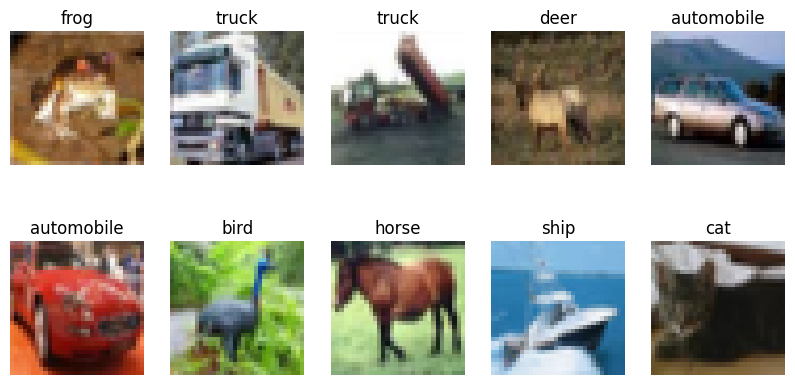

In [7]:
#Visualize Images
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [8]:
#ANN Data Preparation
X_train_ann = X_train.reshape(-1, 32*32*3)
X_test_ann = X_test.reshape(-1, 32*32*3)

print(X_train_ann.shape)

(50000, 3072)


# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [9]:
#ANN Basic Model
ann_basic = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_basic.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_ann_basic = ann_basic.fit(
    X_train_ann, y_train,
    epochs=15,
    validation_split=0.2,
    batch_size=64
)

ann_basic_acc = ann_basic.evaluate(
    X_test_ann,
    y_test,
    verbose=0
)[1]

print("ANN Basic Accuracy:", ann_basic_acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.3176 - loss: 1.9057 - val_accuracy: 0.3594 - val_loss: 1.7925
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.3910 - loss: 1.7012 - val_accuracy: 0.3985 - val_loss: 1.6826
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 17ms/step - accuracy: 0.4208 - loss: 1.6205 - val_accuracy: 0.4242 - val_loss: 1.6220
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.4437 - loss: 1.5603 - val_accuracy: 0.4366 - val_loss: 1.5727
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.4550 - loss: 1.5191 - val_accuracy: 0.4477 - val_loss: 1.5393
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.4686 - loss: 1.4824 - val_accuracy: 0.4569 - val_loss: 1.5222
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.4804 - loss: 1.4556 - val_accuracy: 0.4498 - val_loss: 1.5498
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.4888 - loss: 1.4289 - 

### Observation

A baseline Artificial Neural Network (ANN) was trained using flattened CIFAR-10 images and two dense hidden layers.

Result:
- ANN Basic Accuracy: 48.71%

The model was able to learn basic patterns from the dataset, but its performance remained limited because flattening the images removed important spatial information present in the original image structure.

In [10]:
#Deep ANN Model
ann_deep = models.Sequential([
    layers.Dense(1024, activation='relu', input_shape=(3072,)),
    layers.Dense(512, activation='relu'),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_deep.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_ann_deep = ann_deep.fit(
    X_train_ann, y_train,
    epochs=15,
    validation_split=0.2,
    batch_size=64
)

ann_deep_acc = ann_deep.evaluate(
    X_test_ann,
    y_test,
    verbose=0
)[1]

print("Deep ANN Accuracy:", ann_deep_acc)

Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 29s 44ms/step - accuracy: 0.3018 - loss: 1.9132 - val_accuracy: 0.3601 - val_loss: 1.7661
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 29s 47ms/step - accuracy: 0.3864 - loss: 1.7068 - val_accuracy: 0.4041 - val_loss: 1.6680
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 39s 43ms/step - accuracy: 0.4162 - loss: 1.6273 - val_accuracy: 0.4163 - val_loss: 1.6348
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 27s 43ms/step - accuracy: 0.4385 - loss: 1.5683 - val_accuracy: 0.4395 - val_loss: 1.5588
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 40s 43ms/step - accuracy: 0.4594 - loss: 1.5169 - val_accuracy: 0.4518 - val_loss: 1.5405
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 43ms/step - accuracy: 0.4717 - loss: 1.4778 - val_accuracy: 0.4606 - val_loss: 1.5092
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 27s 43ms/step - accuracy: 0.4821 - loss: 1.4488 - val_accuracy: 0.4563 - val_loss: 1.5146
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 43ms/step - accuracy: 0.4947 - loss: 1.4039 - 

### Observation

The ANN architecture was enhanced by increasing the number of hidden layers and neurons to evaluate whether a deeper network could improve classification performance.

Result:
- ANN Basic Accuracy: 48.71%
- Deep ANN Accuracy: 49.74%

The deeper architecture achieved a slight improvement in accuracy. However, the overall performance remained significantly lower than CNN-based models, indicating that simply increasing network depth is not sufficient for effective image classification.

# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [11]:
#CNN Basic Model
cnn_basic = models.Sequential([
    layers.Conv2D(32,(3,3),activation='relu',input_shape=(32,32,3)),
    layers.MaxPooling2D(),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128,(3,3),activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128,activation='relu'),
    layers.Dense(10,activation='softmax')
])

cnn_basic.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_cnn_basic = cnn_basic.fit(
    X_train,
    y_train,
    epochs=15,
    validation_split=0.2
)

cnn_basic_acc = cnn_basic.evaluate(
    X_test,
    y_test,
    verbose=0
)[1]

print("CNN Basic Accuracy:", cnn_basic_acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 42s 33ms/step - accuracy: 0.4254 - loss: 1.5609 - val_accuracy: 0.5424 - val_loss: 1.2794
Epoch 2/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 38s 30ms/step - accuracy: 0.5800 - loss: 1.1860 - val_accuracy: 0.6066 - val_loss: 1.1223
Epoch 3/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 39s 31ms/step - accuracy: 0.6395 - loss: 1.0224 - val_accuracy: 0.6213 - val_loss: 1.0633
Epoch 4/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 39s 31ms/step - accuracy: 0.6825 - loss: 0.9093 - val_accuracy: 0.6716 - val_loss: 0.9424
Epoch 5/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 38s 29ms/step - accuracy: 0.7122 - loss: 0.8234 - val_accuracy: 0.6885 - val_loss: 0.9041
Epoch 6/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 41s 29ms/step - accuracy: 0.7376 - loss: 0.7512 - val_accuracy: 0.6845 - val_loss: 0.9327
Epoch 7/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 39s 31ms/step - accuracy: 0.7613 - loss: 0.6767 - val_accuracy: 0.7126 - val_loss: 0.8529
Epoch 8/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 37s 29ms/step - accuracy: 0.7790 -

In [12]:
#CNN + Batch Normalization
cnn_bn = models.Sequential([

    layers.Conv2D(32,(3,3),padding='same',
                  activation='relu',
                  input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(64,(3,3),padding='same',
                  activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(128,(3,3),padding='same',
                  activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128,activation='relu'),
    layers.Dense(10,activation='softmax')
])

cnn_bn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_bn = cnn_bn.fit(
    X_train,
    y_train,
    epochs=15,
    validation_split=0.2
)

cnn_bn_acc = cnn_bn.evaluate(
    X_test,
    y_test,
    verbose=0
)[1]

print("CNN BatchNorm Accuracy:", cnn_bn_acc)

Epoch 1/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 81s 63ms/step - accuracy: 0.5453 - loss: 1.2792 - val_accuracy: 0.6247 - val_loss: 1.0635
Epoch 2/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 80s 62ms/step - accuracy: 0.6880 - loss: 0.8865 - val_accuracy: 0.5956 - val_loss: 1.1840
Epoch 3/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 82s 62ms/step - accuracy: 0.7474 - loss: 0.7216 - val_accuracy: 0.6958 - val_loss: 0.8800
Epoch 4/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 78s 62ms/step - accuracy: 0.7867 - loss: 0.6073 - val_accuracy: 0.7031 - val_loss: 0.8859
Epoch 5/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 82s 62ms/step - accuracy: 0.8227 - loss: 0.5033 - val_accuracy: 0.6871 - val_loss: 0.9530
Epoch 6/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 82s 62ms/step - accuracy: 0.8556 - loss: 0.4125 - val_accuracy: 0.6236 - val_loss: 1.2847
Epoch 7/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 78s 62ms/step - accuracy: 0.8859 - loss: 0.3269 - val_accuracy: 0.7074 - val_loss: 1.0617
Epoch 8/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 80s 64ms/step - accuracy: 0.9097 -

### Observation

Batch Normalization layers were added after each convolution layer to evaluate their impact on performance.

Result:
- CNN Basic Accuracy: 69.37%
- CNN + BatchNorm Accuracy: 65.90%

In this experiment, Batch Normalization did not improve test accuracy and performed slightly lower than the Basic CNN model.

In [13]:
#CNN + DropOut
cnn_dropout = models.Sequential([

    layers.Conv2D(32,(3,3),
                  activation='relu',
                  input_shape=(32,32,3)),
    layers.MaxPooling2D(),

    layers.Conv2D(64,(3,3),
                  activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128,(3,3),
                  activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128,activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(10,activation='softmax')
])

cnn_dropout.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_dropout = cnn_dropout.fit(
    X_train,
    y_train,
    epochs=15,
    validation_split=0.2
)

cnn_dropout_acc = cnn_dropout.evaluate(
    X_test,
    y_test,
    verbose=0
)[1]

print("CNN Dropout Accuracy:", cnn_dropout_acc)

Epoch 1/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 41s 32ms/step - accuracy: 0.3722 - loss: 1.6929 - val_accuracy: 0.4780 - val_loss: 1.4434
Epoch 2/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 37s 29ms/step - accuracy: 0.5341 - loss: 1.3114 - val_accuracy: 0.5949 - val_loss: 1.1543
Epoch 3/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 39s 31ms/step - accuracy: 0.5927 - loss: 1.1522 - val_accuracy: 0.6318 - val_loss: 1.0455
Epoch 4/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 36s 29ms/step - accuracy: 0.6342 - loss: 1.0437 - val_accuracy: 0.6512 - val_loss: 0.9868
Epoch 5/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 36s 29ms/step - accuracy: 0.6652 - loss: 0.9616 - val_accuracy: 0.6724 - val_loss: 0.9327
Epoch 6/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 36s 29ms/step - accuracy: 0.6887 - loss: 0.8943 - val_accuracy: 0.6870 - val_loss: 0.8987
Epoch 7/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 44s 31ms/step - accuracy: 0.7109 - loss: 0.8330 - val_accuracy: 0.6950 - val_loss: 0.8668
Epoch 8/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 39s 30ms/step - accuracy: 0.7258 -

### Observation

A Dropout layer (0.5) was added after the dense layer to reduce overfitting.

Result:
- CNN Basic Accuracy: 69.37%
- CNN + Dropout Accuracy: 70.77%

The Dropout model achieved slightly higher accuracy, indicating better generalization on unseen data.

In [14]:
#Data Augmentation
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

datagen.fit(X_train)

## Data Augmentation

Data augmentation is a technique used to artificially increase the diversity of the training dataset by applying random transformations to images. This helps the model generalize better and reduces overfitting.

### Observation

Data augmentation was applied using rotation, shifting, and horizontal flipping to increase the diversity of training images.

This helps the model learn more robust features and reduces overfitting.

In [15]:
#CNN + Augmentation
cnn_aug = models.Sequential([

    layers.Conv2D(32,(3,3),
                  activation='relu',
                  input_shape=(32,32,3)),
    layers.MaxPooling2D(),

    layers.Conv2D(64,(3,3),
                  activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128,(3,3),
                  activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128,activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(10,activation='softmax')
])

cnn_aug.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history_aug = cnn_aug.fit(
    datagen.flow(X_train,y_train,batch_size=64),
    epochs=20,
    validation_data=(X_test,y_test),
    callbacks=[early_stop]
)

cnn_aug_acc = cnn_aug.evaluate(
    X_test,
    y_test,
    verbose=0
)[1]

print("CNN Augmentation Accuracy:", cnn_aug_acc)

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 59s 73ms/step - accuracy: 0.3316 - loss: 1.7940 - val_accuracy: 0.4660 - val_loss: 1.4534
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 57s 73ms/step - accuracy: 0.4601 - loss: 1.4920 - val_accuracy: 0.5373 - val_loss: 1.2803
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 82s 73ms/step - accuracy: 0.5141 - loss: 1.3569 - val_accuracy: 0.5729 - val_loss: 1.2189
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 57s 72ms/step - accuracy: 0.5509 - loss: 1.2709 - val_accuracy: 0.6340 - val_loss: 1.0412
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 57s 73ms/step - accuracy: 0.5776 - loss: 1.2025 - val_accuracy: 0.6487 - val_loss: 1.0020
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 56s 72ms/step - accuracy: 0.5971 - loss: 1.1572 - val_accuracy: 0.6306 - val_loss: 1.0445
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 57s 72ms/step - accuracy: 0.6102 - loss: 1.1171 - val_accuracy: 0.6431 - val_loss: 1.0200
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 60s 76ms/step - accuracy: 0.6248 - loss: 1.0745 - 

### Observation

The augmented dataset was used to train the CNN model along with Early Stopping.

Result:
- CNN + Dropout Accuracy: 70.77%
- CNN + Augmentation Accuracy: 72.51%

Although the maximum number of epochs was set to 20, training automatically stopped after 18 epochs. This happened because the Early Stopping callback detected that the validation loss was no longer improving and terminated training to prevent overfitting.

The CNN with Data Augmentation achieved the highest accuracy among all tested models, indicating better generalization on unseen images.

In [16]:
#Classification Report
pred = cnn_aug.predict(X_test)

pred_classes = np.argmax(pred,axis=1)

print(
    classification_report(
        y_test,
        pred_classes,
        target_names=class_names
    )
)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
              precision    recall  f1-score   support

    airplane       0.81      0.72      0.76      1000
  automobile       0.90      0.81      0.85      1000
        bird       0.66      0.61      0.63      1000
         cat       0.59      0.52      0.55      1000
        deer       0.62      0.74      0.68      1000
         dog       0.69      0.59      0.63      1000
        frog       0.89      0.70      0.78      1000
       horse       0.60      0.88      0.72      1000
        ship       0.82      0.84      0.83      1000
       truck       0.77      0.84      0.81      1000

    accuracy                           0.73     10000
   macro avg       0.74      0.73      0.72     10000
weighted avg       0.74      0.73      0.72     10000



In [17]:
#Accuracy Comparison
results = pd.DataFrame({
    'Model':[
        'ANN Basic',
        'Deep ANN',
        'CNN Basic',
        'CNN BatchNorm',
        'CNN Dropout',
        'CNN Augmentation'
    ],
    'Accuracy':[
        ann_basic_acc,
        ann_deep_acc,
        cnn_basic_acc,
        cnn_bn_acc,
        cnn_dropout_acc,
        cnn_aug_acc
    ]
})

print(results)

              Model  Accuracy
0         ANN Basic    0.4871
1          Deep ANN    0.4974
2         CNN Basic    0.6937
3     CNN BatchNorm    0.6590
4       CNN Dropout    0.7077
5  CNN Augmentation    0.7251


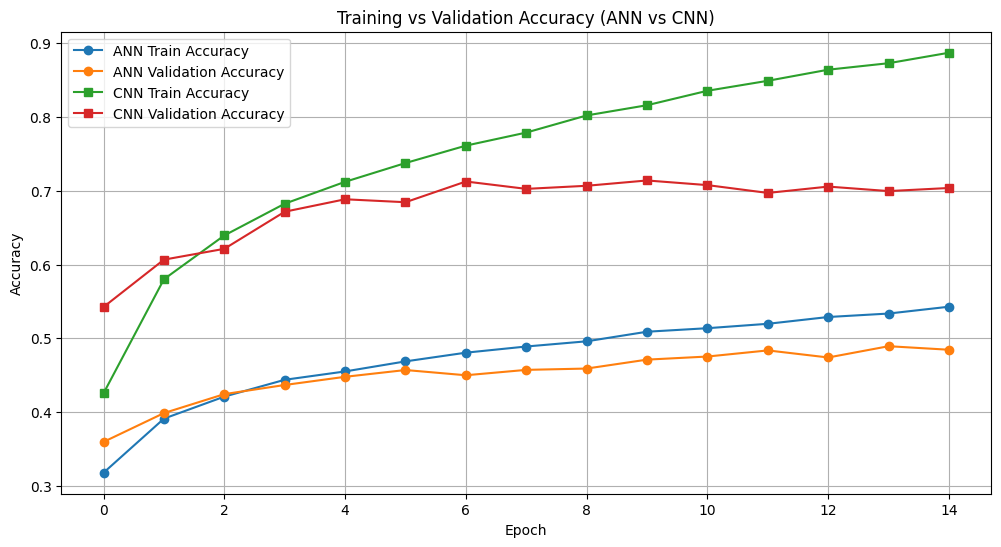

In [20]:
#Accuracy Comparison Graph
plt.figure(figsize=(12,6))

plt.plot(history_ann_basic.history['accuracy'],
         marker='o',
         label='ANN Train Accuracy')

plt.plot(history_ann_basic.history['val_accuracy'],
         marker='o',
         label='ANN Validation Accuracy')

plt.plot(history_cnn_basic.history['accuracy'],
         marker='s',
         label='CNN Train Accuracy')

plt.plot(history_cnn_basic.history['val_accuracy'],
         marker='s',
         label='CNN Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy (ANN vs CNN)")
plt.grid(True)
plt.legend()
plt.show()

### Observation

- CNN achieved significantly higher training and validation accuracy compared to ANN throughout the training process.
- ANN accuracy improved gradually but remained around 50% validation accuracy.
- CNN validation accuracy reached approximately 70%, demonstrating its superior ability to learn image features.
- The gap between CNN training and validation accuracy suggests slight overfitting, but overall generalization remained satisfactory.
- These results confirm that CNN is more suitable than ANN for image classification tasks on the CIFAR-10 dataset.

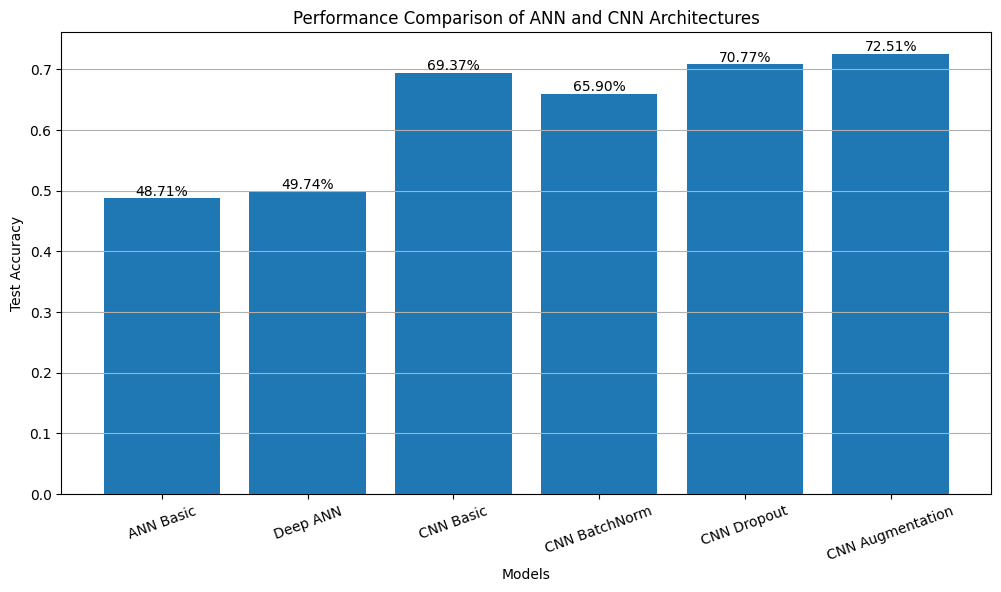

In [22]:
# Performance Comparison Graph of Different Models
plt.figure(figsize=(12,6))

bars = plt.bar(
    results['Model'],
    results['Accuracy']
)

plt.title("Performance Comparison of ANN and CNN Architectures")
plt.xlabel("Models")
plt.ylabel("Test Accuracy")

for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x()+bar.get_width()/2,
        y+0.005,
        f'{y:.2%}',
        ha='center'
    )

plt.xticks(rotation=20)
plt.grid(axis='y')
plt.show()

### Observation

- ANN Basic and Deep ANN achieved accuracies of approximately 48–50%.
- CNN-based models consistently outperformed ANN-based models.
- CNN with Dropout improved accuracy compared to the Basic CNN model.
- CNN with Data Augmentation achieved the highest test accuracy of 72.51%.
- Batch Normalization did not improve performance in this experiment and achieved lower accuracy than the Basic CNN model.
- Overall, CNN with Data Augmentation was the best-performing architecture among all evaluated models.

# 🎓 Student Learning Tasks Completed



1. Increased ANN layers and observe performance
2. Increased CNN filters from 32→64→128
3. Increased epochs to 20
4. Implemented **EarlyStopping**
5. Added **data augmentation and trained the model**

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**

# **Final Observations:**

*   ANN Basic achieved 48.71% accuracy, while Deep ANN achieved 49.74% accuracy.
*   CNN Basic significantly outperformed ANN with 69.37% test accuracy.
*  CNN with Data Augmentation achieved the best performance of 72.51% accuracy.
*   Validation accuracy curves showed that CNN learns image features more effectively than ANN.
*   Dropout and data augmentation improved model performance, with CNN + Data Augmentation achieving the highest test accuracy of 72.51%..
